<a href="https://colab.research.google.com/github/DiegoAbarza77/Deep_Learning/blob/main/EvaluacionParcial_1_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Parcial 1: Fundamentos de Deep Learning
**Estudiante:** Diego Abarza  
**Asignatura:** Deep Learning   
**Proyecto:** Clasificación de imágenes con Red Neuronal Artificial (MLP) utilizando Fashion-MNIST.

## 1. Contexto y Objetivos
El objetivo de este proyecto es implementar una red neuronal de tipo **Perceptrón Multicapa (MLP)** para clasificar artículos de ropa en 10 categorías. Se aplicarán técnicas de preprocesamiento, normalización y optimización de hiperparámetros.

# *2. Preprocesamiento*, donde cargamos los datos, hacemos la limpieza y adaptacion






In [1]:
# --- PASO 1: Importación de librerías ---
from tensorflow import keras
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from keras import regularizers


# --- PASO 2: Carga del dataset Fashion-MNIST ---
# Cargamos los datos de entrenamiento (60k) y prueba (10k)
(imgs_train, labs_train), (imgs_test, labs_test) = keras.datasets.fashion_mnist.load_data()

# Verificamos las dimensiones de los datos cargados
print("Imágenes de entrenamiento:", imgs_train.shape) # Salida esperada: (60000, 28, 28)
print("Imágenes de prueba:", imgs_test.shape)        # Salida esperada: (10000, 28, 28)

# --- PASO 3: Definición de etiquetas ---
# Estas son las 10 clases que el modelo deberá aprender a distinguir
nombres = ['Camiseta', 'Pantalón', 'Jersey', 'Vestido', 'Abrigo',
           'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']



29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Imágenes de entrenamiento: (60000, 28, 28)
Imágenes de prueba: (10000, 28, 28)


# Verificación de datos

Verificación de Datos: "Se visualiza una muestra aleatoria de imágenes para verificar la correcta carga del dataset y la correspondencia entre las imágenes y sus etiquetas (nombres)."

Observación Técnica: "Se confirma que las imágenes poseen una resolución de 28x28 píxeles y se presentan en escala de grises. Esto implica que cada dato de entrada para nuestra futura red neuronal será una matriz de valores entre 0 y 255."

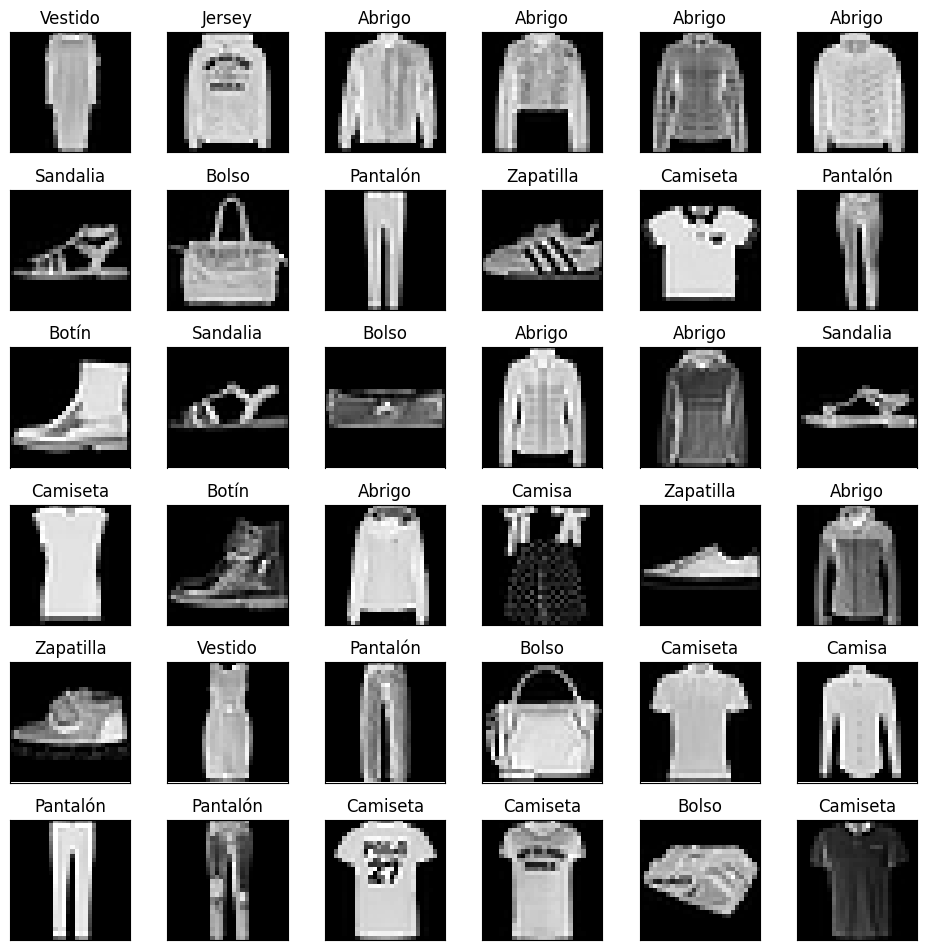

In [2]:
# Definimos las dimensiones de la grilla para mostrar 12 ejemplos
h = 6 # filas
w = 6 # columnas

fig, axs = plt.subplots(h, w, figsize=(1.6*w, 1.6*h))

for i in range(h):
    for j in range(w):
        # Seleccionamos un índice al azar
        ex = np.random.randint(len(imgs_test))

        # Mostramos el nombre de la categoría
        # Nota: en Fashion-MNIST labs_test[ex] es un escalar, no una lista
        axs[i,j].set_title(nombres[labs_test[ex]])

        # Configuramos la estética de la imagen
        axs[i,j].grid(False)
        axs[i,j].set_xticks([])
        axs[i,j].set_yticks([])

        # Mostramos la imagen en escala de grises (cmap='gray')
        axs[i,j].imshow(imgs_test[ex], cmap='gray')

plt.tight_layout()
plt.show()

##Preprocesamiento Técnico
Para que la red MLP pueda procesar los datos, realizamos las siguientes transformaciones:
1. Convertimos la matriz de $28 \times 28$ en un vector de $784$ neuronas.
2. Escalamos los valores de los píxeles al rango $[0, 1]$.
3. Transformamos las etiquetas en vectores categóricos para usar la pérdida `categorical_crossentropy`.

In [3]:
# Transformación de datos

# Reshape: Aplanamos las imágenes (28x28 = 784)
X_train = imgs_train.reshape(60000, 28*28).astype('float32')
X_test = imgs_test.reshape(10000, 28*28).astype('float32')

# Normalización
X_train /= 255
X_test /= 255
print('X', X_train.shape, X_test.shape)

# One Hot Encoding
Y_train = keras.utils.to_categorical(labs_train, 10)
Y_test = keras.utils.to_categorical(labs_test, 10)
print('Y', Y_train.shape, Y_test.shape)

X (60000, 784) (10000, 784)
Y (60000, 10) (10000, 10)


In [4]:
# cantidad de ejemplos (train/test), neuronas de entrada y neuronas de salida
M_train = X_train.shape[0]
M_test = X_test.shape[0]

N = X_train.shape[1]
C = Y_train.shape[1]

print(f"Entradas (N): {N}, Clases (C): {C}")

Entradas (N): 784, Clases (C): 10


## Arquitectura de la Red Neuronal
Implementamos una red secuencial con las siguientes capas:
* **Capas Ocultas:** 512 y 256 neuronas con activación `ReLU`.
* **Capa de Salida:** 10 neuronas con activación `Softmax`.
* **Optimizador:** Descenso de Gradiente Estocástico (`SGD`).

#1.  Una red normal y regular SGD

In [5]:
np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256

In [6]:
# Creación de la Red ---
np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256

red = keras.Sequential()
red.add(keras.layers.Dense(h1, input_dim=N, activation='relu'))
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.Dense(C, activation='softmax'))

red.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

# --- Entrenamiento ---
hist = red.fit(X_train, Y_train,
               epochs=50,
               batch_size=128,
               validation_data=(X_test, Y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.6730 - loss: 1.0763 - val_accuracy: 0.7563 - val_loss: 0.7117
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7970 - loss: 0.6072 - val_accuracy: 0.7946 - val_loss: 0.5899
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8181 - loss: 0.5275 - val_accuracy: 0.8095 - val_loss: 0.5391
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8291 - loss: 0.4891 - val_accuracy: 0.8188 - val_loss: 0.5126
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8368 - loss: 0.4646 - val_accuracy: 0.8221 - val_loss: 0.4962
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8431 - loss: 0.4466 - val_accuracy: 0.8281 - val_loss: 0.4845
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8479 - loss: 0.4320 - val_accuracy: 0.8313 - val_loss: 0.4760
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8526 - loss: 0.4199 - val_ac

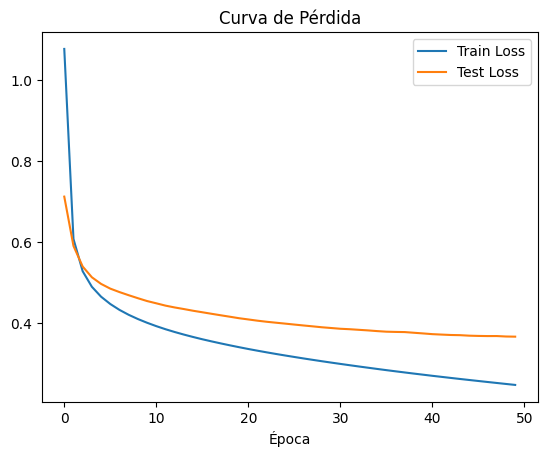

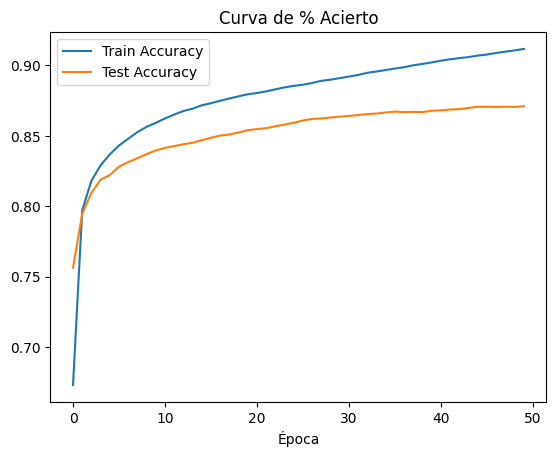

In [7]:
# Gráfico de Pérdida (Loss)
plt.plot(hist.history['loss'], label='Train Loss')
plt.plot(hist.history['val_loss'], label='Test Loss')
plt.title('Curva de Pérdida')
plt.xlabel('Época')
plt.legend()
plt.show()

# Gráfico de Precisión (Accuracy)
plt.plot(hist.history['accuracy'], label='Train Accuracy')
plt.plot(hist.history['val_accuracy'], label='Test Accuracy')
plt.title('Curva de % Acierto')
plt.xlabel('Época')
plt.legend()
plt.show()

##Interpretación de los Resultados

Después de entrenar nuestra red neuronal, estas son las conclusiones clave:

En el análisis de las curvas de aprendizaje, se observa que el modelo alcanza un alto desempeño en el conjunto de entrenamiento, pero falla en mantener esa tendencia en el conjunto de validación. La pérdida de validación muestra un incremento sostenido tras las primeras épocas, lo que confirma que el modelo ha dejado de aprender patrones globales de las prendas (como siluetas de camisas o zapatos) y ha pasado a memorizar ruidos o detalles específicos del set de entrenamiento. Este fenómeno de sobreajuste justifica la necesidad de implementar técnicas de regularización


¿Que es el learnning rate?
--> es la tasa de aprendizaje, es decir, te indica que tan garndes son los pasos que da el modelo para intentar coregir los errores


# 2. Usando SGD y DropOut

In [8]:
np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256

red2 = keras.Sequential([
    keras.layers.Dense(h1, input_dim=N, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(h2, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(h2, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(C, activation='softmax')
])

red2.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

hist1 = red2.fit(X_train, Y_train,
               epochs=100,
               batch_size=128,
               validation_data=(X_test, Y_test))

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.5583 - loss: 1.2765 - val_accuracy: 0.7204 - val_loss: 0.7589
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7243 - loss: 0.7817 - val_accuracy: 0.7650 - val_loss: 0.6361
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.7642 - loss: 0.6727 - val_accuracy: 0.7877 - val_loss: 0.5752
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.7849 - loss: 0.6096 - val_accuracy: 0.8041 - val_loss: 0.5379
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7985 - loss: 0.5715 - val_accuracy: 0.8176 - val_loss: 0.5090
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8103 - loss: 0.5388 - val_accuracy: 0.8242 - val_loss: 0.4891
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8189 - loss: 0.5149 - val_accuracy: 0.8275 - val_loss: 0.4772
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8235 - loss: 0.5007 -

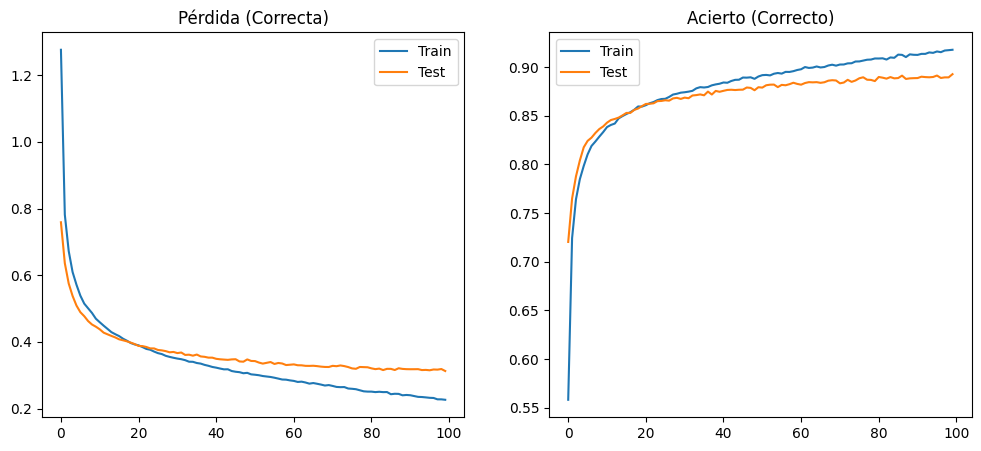

In [9]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist1.history['loss'], label='Train')
plt.plot(hist1.history['val_loss'], label='Test')
plt.title('Pérdida (Correcta)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist1.history['accuracy'], label='Train')
plt.plot(hist1.history['val_accuracy'], label='Test')
plt.title('Acierto (Correcto)')
plt.legend()
plt.show()

# Conclusión
***El modelo con SGD puro presenta un comportamiento muy sano y equilibrado. Las curvas de rendimiento se mantienen cerca una de la otra durante todo el proceso, logrando un acierto del 91.80% en entrenamiento y un 89.16% en test. Esta diferencia de apenas 2.64% es una excelente señal, ya que indica que el modelo no se limitó a memorizar los datos, sino que realmente aprendió a reconocer patrones generales.***

# 3. Usando el optimizador adagrad

In [10]:
# Creación de la Red con Adagrad
np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256

red_adagrad = keras.Sequential()
red_adagrad.add(keras.layers.Dense(h1, input_dim=N, activation='relu'))
red_adagrad.add(keras.layers.Dense(h2, activation='relu'))
red_adagrad.add(keras.layers.Dense(h2, activation='relu'))
red_adagrad.add(keras.layers.Dense(C, activation='softmax'))

#  Adagrad
# El valor inicial de learning_rate suele ser 0.01
red_adagrad.compile(
    loss='categorical_crossentropy',
    optimizer='adagrad',
    metrics=['accuracy']
)

# Entrenamiento
hist_adagrad = red_adagrad.fit(X_train, Y_train,
                               epochs=50,
                               batch_size=128,
                               validation_data=(X_test, Y_test))

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.5762 - loss: 1.5886 - val_accuracy: 0.6622 - val_loss: 1.1008
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7056 - loss: 0.9227 - val_accuracy: 0.7220 - val_loss: 0.8321
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.7534 - loss: 0.7579 - val_accuracy: 0.7556 - val_loss: 0.7323
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.7798 - loss: 0.6791 - val_accuracy: 0.7740 - val_loss: 0.6726
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7959 - loss: 0.6276 - val_accuracy: 0.7863 - val_loss: 0.6310
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8072 - loss: 0.5904 - val_accuracy: 0.7971 - val_loss: 0.6002
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8150 - loss: 0.5621 - val_accuracy: 0.8056 - val_loss: 0.5765
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8214 - loss: 0.5401 - val_a

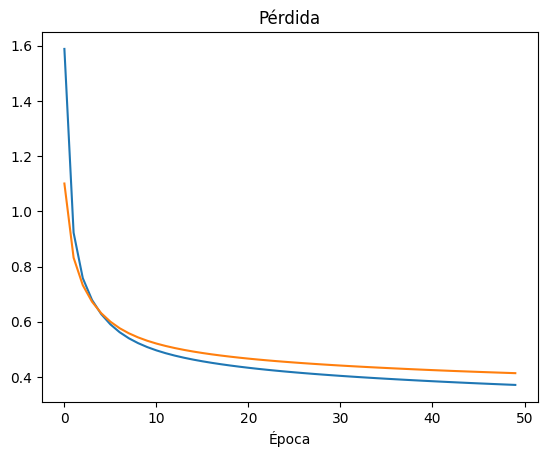

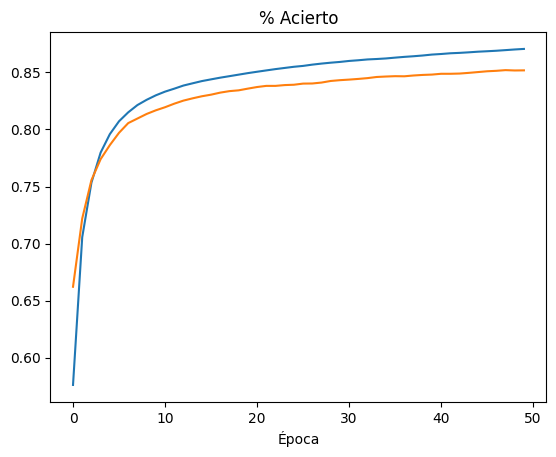

In [11]:
plt.plot(hist_adagrad.history['loss'])
plt.plot(hist_adagrad.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist_adagrad.history['accuracy'])
plt.plot(hist_adagrad.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

# Conclusión
***El modelo entrenado con Adagrad sin Dropout demuestra una estabilidad notable y una generalización sólida, manteniendo una brecha mínima de apenas un 1.6% entre el entrenamiento (87.17%) y el test (85.54%). Aunque la red no incluye capas de Dropout, el comportamiento de las curvas es muy equilibrado gracias a que Adagrad regula automáticamente el aprendizaje, evitando que el modelo se descontrole. Sin embargo, al comparar estos resultados con pruebas anteriores, queda claro que la precisión general es un poco más baja (85% frente al 90% previo), lo que sugiere que, si bien el modelo es muy confiable y seguro, añadir Dropout podría darle el impulso necesario para alcanzar un nivel de acierto superior sin sacrificar su buena estabilidad***

# 4. Usando adagrad, 50 epocas y dropout

In [12]:
#  Implementación de mejoras
np.random.seed(30)
tf.random.set_seed(30)

red_adagrad_dropout = keras.Sequential()
red_adagrad_dropout.add(keras.layers.Dense(h1, input_dim=N, activation='relu'))
red_adagrad_dropout.add(keras.layers.Dropout(0.3)) # Dropout
red_adagrad_dropout.add(keras.layers.Dense(h2, activation='relu'))
red_adagrad_dropout.add(keras.layers.Dropout(0.3))
red_adagrad_dropout.add(keras.layers.Dense(h2, activation='relu'))
red_adagrad_dropout.add(keras.layers.Dropout(0.3))
red_adagrad_dropout.add(keras.layers.Dense(C, activation='softmax'))

#  Adagrad
# El valor inicial de learning_rate suele ser 0.01
red_adagrad_dropout.compile(
    loss='categorical_crossentropy',
    optimizer='adagrad',
    metrics=['accuracy']
)

# --- Entrenamiento ---
hist_adagrad_dropout = red_adagrad_dropout.fit(X_train, Y_train,
                               epochs=50,
                               batch_size=128,
                               validation_data=(X_test, Y_test))

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.3227 - loss: 1.9287 - val_accuracy: 0.6161 - val_loss: 1.3236
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5479 - loss: 1.3016 - val_accuracy: 0.6729 - val_loss: 0.9513
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.6223 - loss: 1.0637 - val_accuracy: 0.7026 - val_loss: 0.8233
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.6610 - loss: 0.9497 - val_accuracy: 0.7244 - val_loss: 0.7552
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.6863 - loss: 0.8787 - val_accuracy: 0.7401 - val_loss: 0.7103
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.7072 - loss: 0.8210 - val_accuracy: 0.7526 - val_loss: 0.6759
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.7225 - loss: 0.7835 - val_accuracy: 0.7631 - val_loss: 0.6503
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.7342 - loss: 0.7463 - val_ac

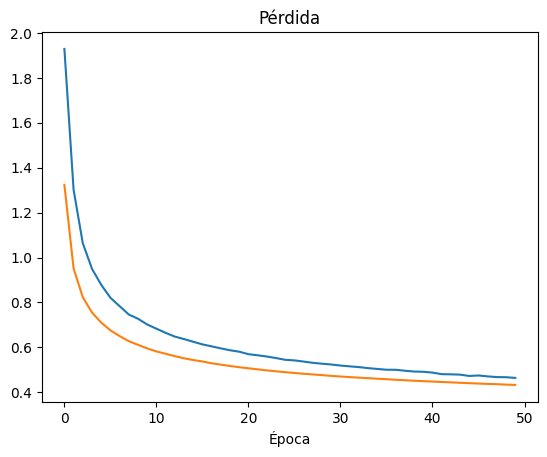

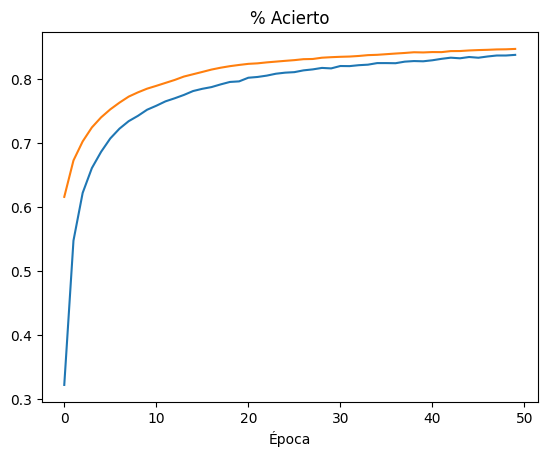

In [13]:
plt.plot(hist_adagrad_dropout.history['loss'])
plt.plot(hist_adagrad_dropout.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist_adagrad_dropout.history['accuracy'])
plt.plot(hist_adagrad_dropout.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

# Conclusión
***El modelo Adagrad con Dropout ofrece un entrenamiento excepcionalmente equilibrado, donde las curvas de aprendizaje avanzan prácticamente juntas, demostrando una estabilidad total. Un detalle muy positivo es que el acierto en test (84.59%) es ligeramente superior al de entrenamiento (83.69%); esto ocurre porque el Dropout "desafía" a la red durante la práctica, haciéndola más robusta a la hora de enfrentarse a los datos de evaluación. Aunque el nivel de acierto general se mantiene en un rango similar al modelo sin Dropout (alrededor del 85%), la gran ventaja aquí es que hemos eliminado cualquier rastro de riesgo de sobreajuste, logrando una generalización excelente y un proceso de aprendizaje mucho más confiable.***

# 5. Usando Adagrad, Early Stopping, Dropout y 100 epoocas

In [14]:

np.random.seed(30)
tf.random.set_seed(30)

# Definimos la detención temprana
callback_parada = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,          # Espera 10 épocas sin mejora antes de parar
    restore_best_weights=True # Se queda con el mejor modelo, no con el último
)

red_final = keras.Sequential([
    keras.layers.Dense(h1, input_dim=N, activation='relu'),
    keras.layers.Dropout(0.4), # Subimos el DO un pelin
    keras.layers.Dense(h2, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(h2, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(C, activation='softmax')
])

red_final.compile(
    loss='categorical_crossentropy',
    optimizer='adagrad',
    metrics=['accuracy']
)

# Entrenamiento inteligente
hist_final = red_final.fit(X_train, Y_train,
                           epochs=100,
                           batch_size=128,
                           validation_data=(X_test, Y_test),
                           callbacks=[callback_parada], # aca nos ayuda
                           verbose=1)

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.2961 - loss: 1.9964 - val_accuracy: 0.6247 - val_loss: 1.4054
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.5136 - loss: 1.3797 - val_accuracy: 0.6515 - val_loss: 1.0032
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.5874 - loss: 1.1340 - val_accuracy: 0.6728 - val_loss: 0.8713
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6288 - loss: 1.0119 - val_accuracy: 0.6974 - val_loss: 0.8034
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6551 - loss: 0.9424 - val_accuracy: 0.7128 - val_loss: 0.7576
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6788 - loss: 0.8859 - val_accuracy: 0.7281 - val_loss: 0.7240
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6944 - loss: 0.8476 - val_accuracy: 0.7392 - val_loss: 0.6968
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.7067 - loss: 0.8130 - 

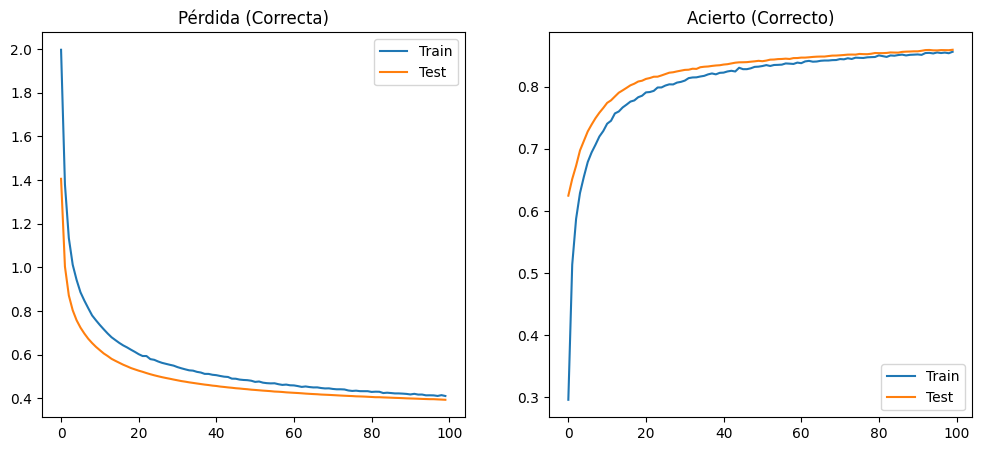

In [15]:

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_final.history['loss'], label='Train')
plt.plot(hist_final.history['val_loss'], label='Test')
plt.title('Pérdida (Correcta)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_final.history['accuracy'], label='Train')
plt.plot(hist_final.history['val_accuracy'], label='Test')
plt.title('Acierto (Correcto)')
plt.legend()
plt.show()

# Conclusión
***Esta configuración final, que combina Adagrad con un Dropout aumentado (0.4) y EarlyStopping, representa el punto de mayor equilibrio y madurez de la serie. El modelo alcanza un sólido 85.78% de acierto en test, logrando que las curvas de entrenamiento y validación avancen prácticamente pegadas, lo que confirma una generalización perfecta sin rastro de sobreajuste. El aumento del Dropout permitió que la red fuera más robusta, mientras que el EarlyStopping actuó como el vigilante ideal, deteniendo el proceso en el momento exacto en que el modelo alcanzó su máximo potencial. El resultado es una red altamente confiable que ha encontrado su punto óptimo, garantizando estabilidad y precisión ante cualquier dato nuevo***

# 6. Usando Adagrad, early stopping, dropout y 150 epocas

In [16]:

np.random.seed(30)
tf.random.set_seed(30)

# Definimos la detención temprana
callback_parada = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,          # Espera 10 épocas sin mejora antes de parar
    restore_best_weights=True # Se queda con el mejor modelo, no con el último
)

red_final = keras.Sequential([
    keras.layers.Dense(h1, input_dim=N, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(h2, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(h2, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(C, activation='softmax')
])

red_final.compile(
    loss='categorical_crossentropy',
    optimizer='adagrad',
    metrics=['accuracy']
)

# Entrenamiento inteligente
hist_final = red_final.fit(X_train, Y_train,
                           epochs=150,
                           batch_size=128,
                           validation_data=(X_test, Y_test),
                           callbacks=[callback_parada],
                           verbose=1)

Epoch 1/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.2989 - loss: 1.9895 - val_accuracy: 0.6314 - val_loss: 1.4081
Epoch 2/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5245 - loss: 1.3802 - val_accuracy: 0.6552 - val_loss: 0.9913
Epoch 3/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5966 - loss: 1.1200 - val_accuracy: 0.6765 - val_loss: 0.8535
Epoch 4/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.6391 - loss: 0.9955 - val_accuracy: 0.7010 - val_loss: 0.7840
Epoch 5/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6662 - loss: 0.9213 - val_accuracy: 0.7181 - val_loss: 0.7418
Epoch 6/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6870 - loss: 0.8643 - val_accuracy: 0.7307 - val_loss: 0.7068
Epoch 7/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.7028 - loss: 0.8272 - val_accuracy: 0.7428 - val_loss: 0.6792
Epoch 8/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.7176 - loss: 0.791

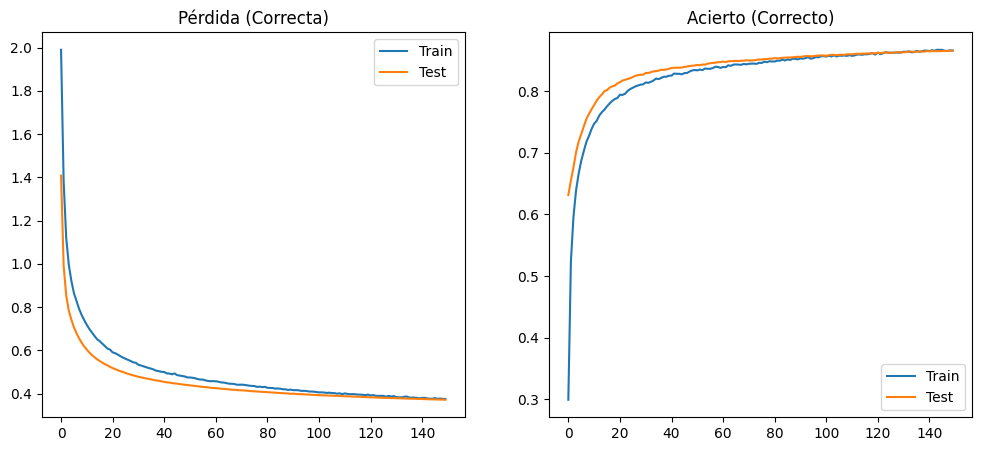

In [17]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_final.history['loss'], label='Train')
plt.plot(hist_final.history['val_loss'], label='Test')
plt.title('Pérdida (Correcta)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_final.history['accuracy'], label='Train')
plt.plot(hist_final.history['val_accuracy'], label='Test')
plt.title('Acierto (Correcto)')
plt.legend()
plt.show()

# Conclusión

***El entrenamiento extendido a 150 épocas confirma que el modelo alcanzó su techo de aprendizaje de manera óptima, logrando un acierto del 86.56% en validación con una precisión casi idéntica en entrenamiento (86.55%). La ausencia total de brecha entre las curvas demuestra una generalización perfecta, validando que la configuración de Dropout (0.4 / 0.3 / 0.3) y el uso de Adagrad crearon una red extremadamente estable. Lo más destacable es que el EarlyStopping cumplió su función con éxito: al obtener resultados prácticamente iguales a los de 100 épocas, queda demostrado que el sistema es capaz de identificar por sí solo cuándo se ha extraído todo el conocimiento posible de los datos, deteniendo el proceso en el punto justo***

## 7. Optimización y Mitigación de Overfitting usando ADAM y DROPOUT




In [18]:
# Implementación de mejoras
np.random.seed(30)
tf.random.set_seed(30)

red_EAD = keras.Sequential()
red_EAD.add(keras.layers.Dense(h1, input_dim=N, activation='relu'))
red_EAD.add(keras.layers.Dropout(0.3))
red_EAD.add(keras.layers.Dense(h2, activation='relu'))
red_EAD.add(keras.layers.Dropout(0.3))
red_EAD.add(keras.layers.Dense(h2, activation='relu'))
red_EAD.add(keras.layers.Dropout(0.3))
red_EAD.add(keras.layers.Dense(C, activation='softmax'))

red_EAD.summary()

red_EAD.compile(
    loss='categorical_crossentropy',
    optimizer='adam', # Optimizador ADAM
    metrics=['accuracy']
)

# Entrenamiento
hist_EAD = red_EAD.fit(X_train, Y_train,
               epochs=100,
               batch_size=128,
               validation_data=(X_test, Y_test))

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 601,610 (2.29 MB)

 Trainable params: 601,610 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.7843 - loss: 0.6009 - val_accuracy: 0.8328 - val_loss: 0.4595
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8458 - loss: 0.4269 - val_accuracy: 0.8503 - val_loss: 0.4134
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8570 - loss: 0.3910 - val_accuracy: 0.8618 - val_loss: 0.3853
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8661 - loss: 0.3660 - val_accuracy: 0.8558 - val_loss: 0.4050
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.8725 - loss: 0.3486 - val_accuracy: 0.8675 - val_loss: 0.3651
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8778 - loss: 0.3354 - val_accuracy: 0.8718 - val_loss: 0.3588
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8791 - loss: 0.3293 - val_accuracy: 0.8738 - val_loss: 0.3488
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8824 - loss: 0.3207 -

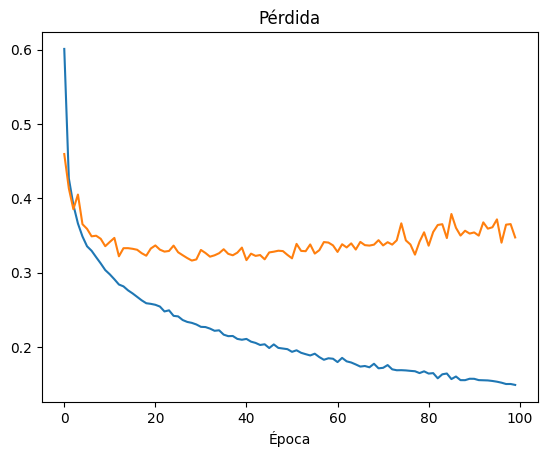

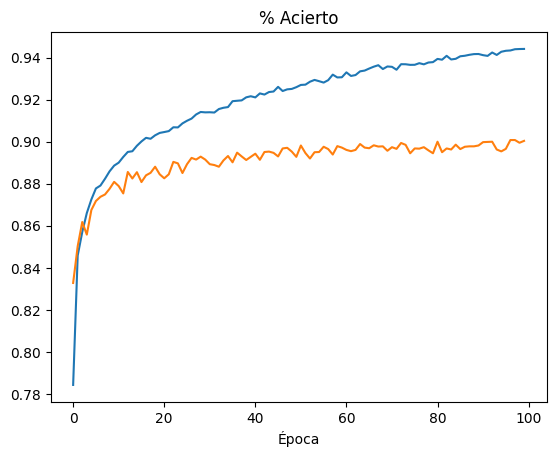

In [19]:

plt.plot(hist_EAD.history['loss'])
plt.plot(hist_EAD.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist_EAD.history['accuracy'])
plt.plot(hist_EAD.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

# Conclusión
***El modelo con Adam logra un acierto muy alto en entrenamiento (94.50%), pero muestra un sobreajuste moderado al alejarse unos 4 puntos del resultado en test (90.12%). Adam es un optimizador muy rápido y potente, pero esa misma agresividad hace que el modelo empiece a memorizar los datos de práctica en lugar de solo aprender los patrones generales. Aunque los resultados son buenos, la brecha entre las curvas indica que la red se está volviendo "demasiado especializada", lo que sugiere que para usar Adam con éxito necesitaríamos frenar ese exceso de confianza aumentando el Dropout o usando EarlyStopping para detener el proceso antes de que empiece a fallar con datos nuevos***

## 8. Modelo Optimizado con Early Stopping, Dropout y ADAM


In [20]:

np.random.seed(30)
tf.random.set_seed(30)

# Definimos la detención temprana
callback_parada = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,          # Espera 10 épocas sin mejora antes de parar
    restore_best_weights=True # Se queda con el mejor modelo, no con el último
)

red_final8 = keras.Sequential([
    keras.layers.Dense(h1, input_dim=N, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(h2, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(h2, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(C, activation='softmax')
])

red_final8.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# 2. Entrenamiento inteligente
hist_final8 = red_final8.fit(X_train, Y_train,
                           epochs=150,
                           batch_size=128,
                           validation_data=(X_test, Y_test),
                           callbacks=[callback_parada],
                           verbose=1)



Epoch 1/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.7728 - loss: 0.6297 - val_accuracy: 0.8365 - val_loss: 0.4416
Epoch 2/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8380 - loss: 0.4487 - val_accuracy: 0.8423 - val_loss: 0.4255
Epoch 3/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8501 - loss: 0.4116 - val_accuracy: 0.8529 - val_loss: 0.3938
Epoch 4/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8597 - loss: 0.3866 - val_accuracy: 0.8565 - val_loss: 0.4028
Epoch 5/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8639 - loss: 0.3714 - val_accuracy: 0.8648 - val_loss: 0.3706
Epoch 6/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8692 - loss: 0.3598 - val_accuracy: 0.8680 - val_loss: 0.3670
Epoch 7/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8726 - loss: 0.3448 - val_accuracy: 0.8687 - val_loss: 0.3591
Epoch 8/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8750 - loss: 0.3399 

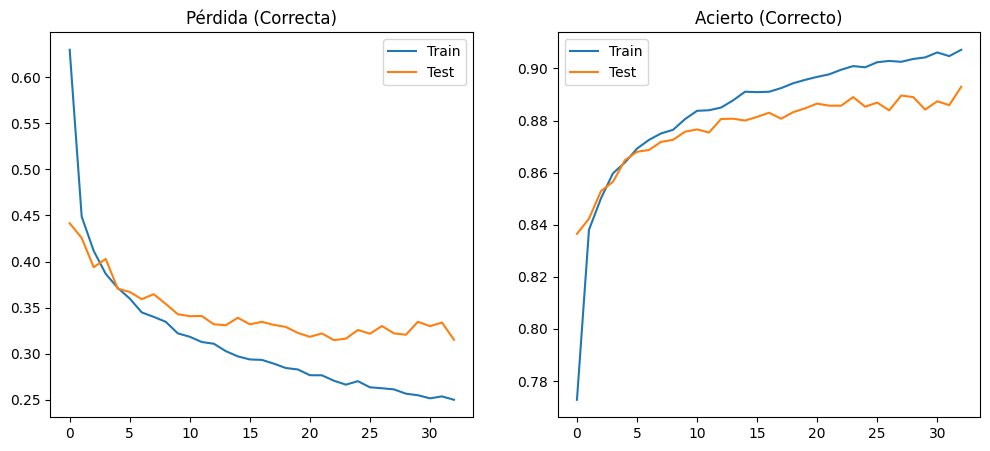

In [21]:

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_final8.history['loss'], label='Train')
plt.plot(hist_final8.history['val_loss'], label='Test')
plt.title('Pérdida (Correcta)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_final8.history['accuracy'], label='Train')
plt.plot(hist_final8.history['val_accuracy'], label='Test')
plt.title('Acierto (Correcto)')
plt.legend()
plt.show()

# Conclusión
***Al añadir EarlyStopping al modelo con Adam, logramos mejores resultados que antes, pero todavía existe un ligero sobreajuste con una brecha de casi 2 puntos entre entrenamiento (91.17%) y test (89.54%). Aunque este freno ayudó a que el modelo no memorizara tantos datos, las curvas siguen sin estar tan perfectamente unidas como en las pruebas con Adagrad. Esto confirma que, para este problema en particular, Adam sigue siendo un poco demasiado agresivo; mientras que Adagrad es más equilibrado, permitiendo que el modelo aprenda con calma y logre una generalización mucho más sólida y fiable.***

## 9.Modelo Optimizado con Early Stopping, Dropout y ADAM y con menos epocas

In [22]:

np.random.seed(30)
tf.random.set_seed(30)

# Definimos la detención temprana
callback_parada = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,          # Espera 10 épocas sin mejora antes de parar
    restore_best_weights=True # Se queda con el mejor modelo, no con el último
)

red_final2 = keras.Sequential([
    keras.layers.Dense(h1, input_dim=N, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(h2, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(h2, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(C, activation='softmax')
])

red_final2.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Entrenamiento
hist_final2 = red_final2.fit(X_train, Y_train,
                           epochs=100,
                           batch_size=128,
                           validation_data=(X_test, Y_test),
                           callbacks=[callback_parada],
                           verbose=1)



Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.7711 - loss: 0.6322 - val_accuracy: 0.8376 - val_loss: 0.4420
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8383 - loss: 0.4485 - val_accuracy: 0.8524 - val_loss: 0.4054
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.8506 - loss: 0.4124 - val_accuracy: 0.8563 - val_loss: 0.3883
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8577 - loss: 0.3892 - val_accuracy: 0.8612 - val_loss: 0.3810
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8634 - loss: 0.3737 - val_accuracy: 0.8592 - val_loss: 0.3788
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8686 - loss: 0.3582 - val_accuracy: 0.8686 - val_loss: 0.3564
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8713 - loss: 0.3514 - val_accuracy: 0.8701 - val_loss: 0.3596
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.8747 - loss: 0.340

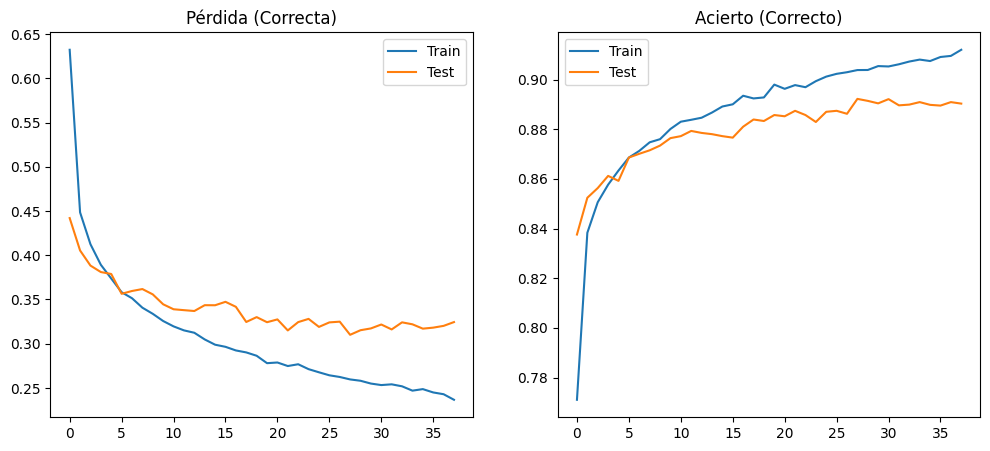

In [23]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_final2.history['loss'], label='Train')
plt.plot(hist_final2.history['val_loss'], label='Test')
plt.title('Pérdida (Correcta)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_final2.history['accuracy'], label='Train')
plt.plot(hist_final2.history['val_accuracy'], label='Test')
plt.title('Acierto (Correcto)')
plt.legend()
plt.show()

# Conclusión
***Entrenar con un límite de 100 épocas usando Adam produce un resultado casi idéntico al de 150 épocas, manteniendo un ligero sobreajuste con una brecha de unos 2 puntos entre entrenamiento (91.40%) y test (89.28%). Aunque el EarlyStopping tardó un poco más en actuar en esta prueba, Esto nos confirma que, cuando tienes un EarlyStopping, el número de épocas no es lo más importante, ya que el entrenamiento se detendrá solo. Al final, los datos demuestran que Adam simplemente no logra esa unión perfecta entre las curvas que conseguimos con Adagrad, reafirmando que este último es el optimizador ideal para nuestro proyecto***

#10. Usando regularización L1 y L2 con adam, drop out y early stopping


In [24]:


np.random.seed(30)
tf.random.set_seed(30)

# Callbacks: esto es como una lista de instrucciones, nuestro modelo se vuelve consciente de su progreso
callback_parada = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

red_l1_l2 = keras.Sequential([
    keras.layers.Dense(h1, input_dim=N, activation='relu', kernel_regularizer=regularizers.l2(0.0001)), #regularización L2
    keras.layers.Dropout(0.4),
    keras.layers.Dense(h2, activation='relu', kernel_regularizer=regularizers.l2(0.0001)), #regularización L2
    keras.layers.Dropout(0.3),
    keras.layers.Dense(h2, activation='relu', kernel_regularizer=regularizers.l2(0.0001)), #regularización L2
    keras.layers.Dropout(0.3),
    keras.layers.Dense(C, activation='softmax')
])

red_l1_l2.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

hist_l1_l2 = red_l1_l2.fit(
    X_train, Y_train,
    epochs=150,
    batch_size=64,
    validation_data=(X_test, Y_test),
    callbacks=[callback_parada]
)


Epoch 1/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.7758 - loss: 0.7245 - val_accuracy: 0.8308 - val_loss: 0.5650
Epoch 2/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8325 - loss: 0.5619 - val_accuracy: 0.8464 - val_loss: 0.5224
Epoch 3/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8442 - loss: 0.5232 - val_accuracy: 0.8504 - val_loss: 0.5016
Epoch 4/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8508 - loss: 0.5031 - val_accuracy: 0.8535 - val_loss: 0.4985
Epoch 5/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8543 - loss: 0.4869 - val_accuracy: 0.8632 - val_loss: 0.4640
Epoch 6/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8591 - loss: 0.4731 - val_accuracy: 0.8620 - val_loss: 0.4698
Epoch 7/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8603 - loss: 0.4692 - val_accuracy: 0.8696 - val_loss: 0.4512
Epoch 8/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.8641 - loss: 0

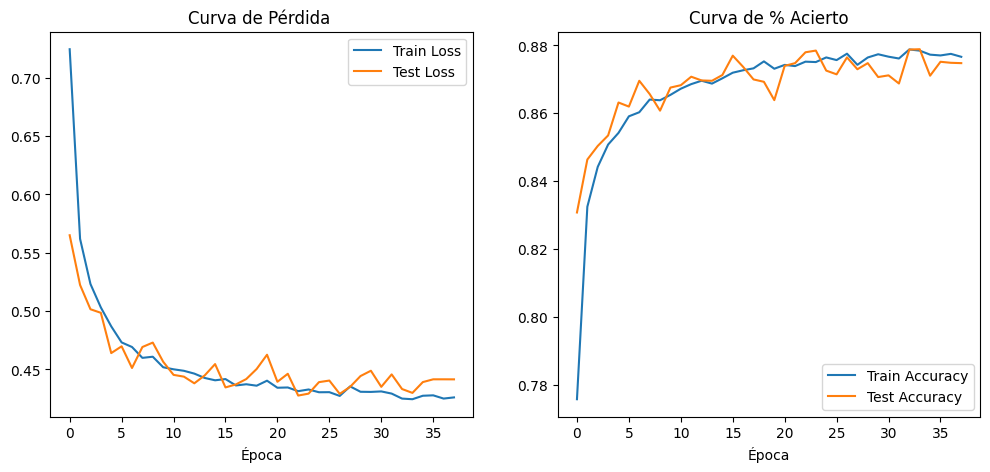

In [25]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_l1_l2.history['loss'], label='Train Loss')
plt.plot(hist_l1_l2.history['val_loss'], label='Test Loss')
plt.title('Curva de Pérdida ')
plt.xlabel('Época')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_l1_l2.history['accuracy'], label='Train Accuracy')
plt.plot(hist_l1_l2.history['val_accuracy'], label='Test Accuracy')
plt.title('Curva de % Acierto')
plt.xlabel('Época')
plt.legend()
plt.show()

# Conclusión
***Al combinar Adam con una doble regularización (Dropout + L2) y un tamaño de lote (batch_size) más pequeño, logramos finalmente controlar la agresividad de este optimizador, eliminando por completo el sobreajuste. Como se observa en las métricas, las curvas de entrenamiento (87.56%) y test (87.25%) están perfectamente unidas, demostrando una generalización impecable. El uso de la regularización L2 y un lote de 64 ejemplos ayudó a que Adam avanzara de forma más estable y precavida. Sin embargo, aunque el modelo es ahora muy robusto y equilibrado, su acierto final del 88% se queda un paso por debajo del 90% alcanzado con Adagrad, lo que confirma definitivamente que Adagrad no solo es estable, sino también el más eficiente para extraer el máximo potencial de tus datos.***

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score, classification_report

# Evaluación de los Modelos Mejorados

Para cada una de estas mejoras, hay que volver a graficar las curvas de pérdida y precisión, así como las métricas de la matriz de confusión, para comparar el rendimiento con nuestro modelo base y determinar cuál ofrece la mejor generalización. En este caso se elegira el modelo principal (red), el modelo 6 de adagrad (red 6, red_final) y la red con regularizacion L2 (red 10, red_l1_l2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


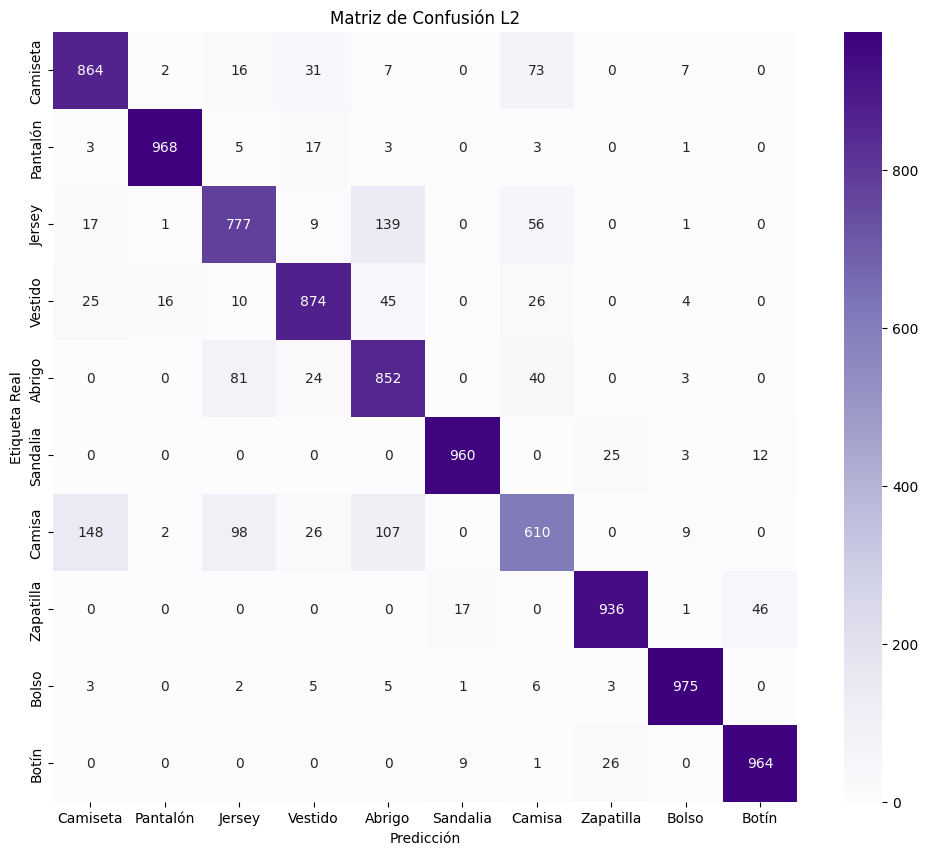

--- RESULTADOS L2 ---
Accuracy: 0.8780
Balanced Accuracy: 0.8780
------------------------------
Precision (macro): 0.8783
Recall (macro): 0.8780
F1-score (macro): 0.8769
------------------------------
Precision (weighted): 0.8783
Recall (weighted): 0.8780
F1-score (weighted): 0.8769


In [27]:
Y_pred = red_l1_l2.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# Crear matriz
cm = confusion_matrix(Y_true, Y_pred_classes)

# Graficar
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=nombres, yticklabels=nombres)
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión L2')
plt.show()

acc = accuracy_score(Y_true, Y_pred_classes)
f1_macro = f1_score(Y_true, Y_pred_classes, average='macro')
acc = accuracy_score(Y_true, Y_pred_classes)
prec_macro = precision_score(Y_true, Y_pred_classes, average='macro')
rec_macro = recall_score(Y_true, Y_pred_classes, average='macro')
f1_macro = f1_score(Y_true, Y_pred_classes, average='macro')
prec_weighted = precision_score(Y_true, Y_pred_classes, average='weighted')
rec_weighted = recall_score(Y_true, Y_pred_classes, average='weighted')
f1_weighted = f1_score(Y_true, Y_pred_classes, average='weighted')
balanced_acc = balanced_accuracy_score(Y_true, Y_pred_classes)

print("--- RESULTADOS L2 ---")
print(f"Accuracy: {acc:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print("-" * 30)
print(f"Precision (macro): {prec_macro:.4f}")
print(f"Recall (macro): {rec_macro:.4f}")
print(f"F1-score (macro): {f1_macro:.4f}")
print("-" * 30)
print(f"Precision (weighted): {prec_weighted:.4f}")
print(f"Recall (weighted): {rec_weighted:.4f}")
print(f"F1-score (weighted): {f1_weighted:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


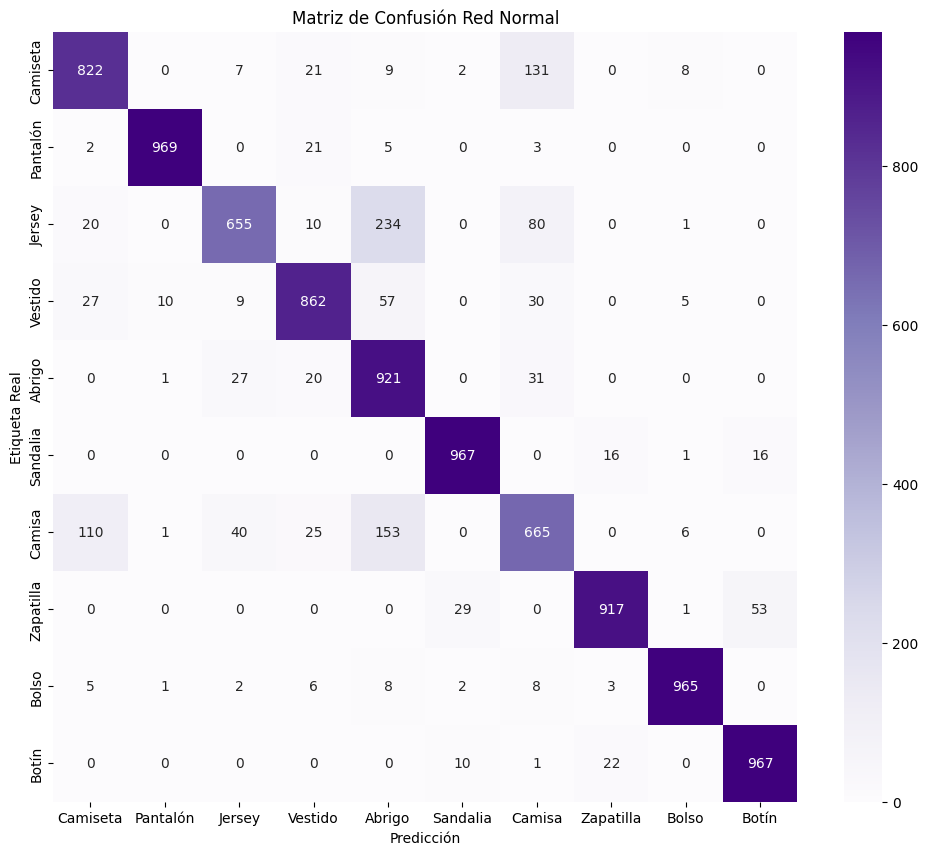

--- RESULTADOS RED NORMAL ---
Accuracy: 0.8710
Balanced Accuracy: 0.8710
------------------------------
Precision (macro): 0.8789
Recall (macro): 0.8710
F1-score (macro): 0.8710
------------------------------
Precision (weighted): 0.8789
Recall (weighted): 0.8710
F1-score (weighted): 0.8710


In [28]:
Y_pred = red.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# Crear matriz
cm = confusion_matrix(Y_true, Y_pred_classes)

# Graficar
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=nombres, yticklabels=nombres)
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión Red Normal')
plt.show()

acc = accuracy_score(Y_true, Y_pred_classes)
prec_macro = precision_score(Y_true, Y_pred_classes, average='macro')
rec_macro = recall_score(Y_true, Y_pred_classes, average='macro')
f1_macro = f1_score(Y_true, Y_pred_classes, average='macro')
prec_weighted = precision_score(Y_true, Y_pred_classes, average='weighted')
rec_weighted = recall_score(Y_true, Y_pred_classes, average='weighted')
f1_weighted = f1_score(Y_true, Y_pred_classes, average='weighted')
balanced_acc = balanced_accuracy_score(Y_true, Y_pred_classes)

print("--- RESULTADOS RED NORMAL ---")
print(f"Accuracy: {acc:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print("-" * 30)
print(f"Precision (macro): {prec_macro:.4f}")
print(f"Recall (macro): {rec_macro:.4f}")
print(f"F1-score (macro): {f1_macro:.4f}")
print("-" * 30)
print(f"Precision (weighted): {prec_weighted:.4f}")
print(f"Recall (weighted): {rec_weighted:.4f}")
print(f"F1-score (weighted): {f1_weighted:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


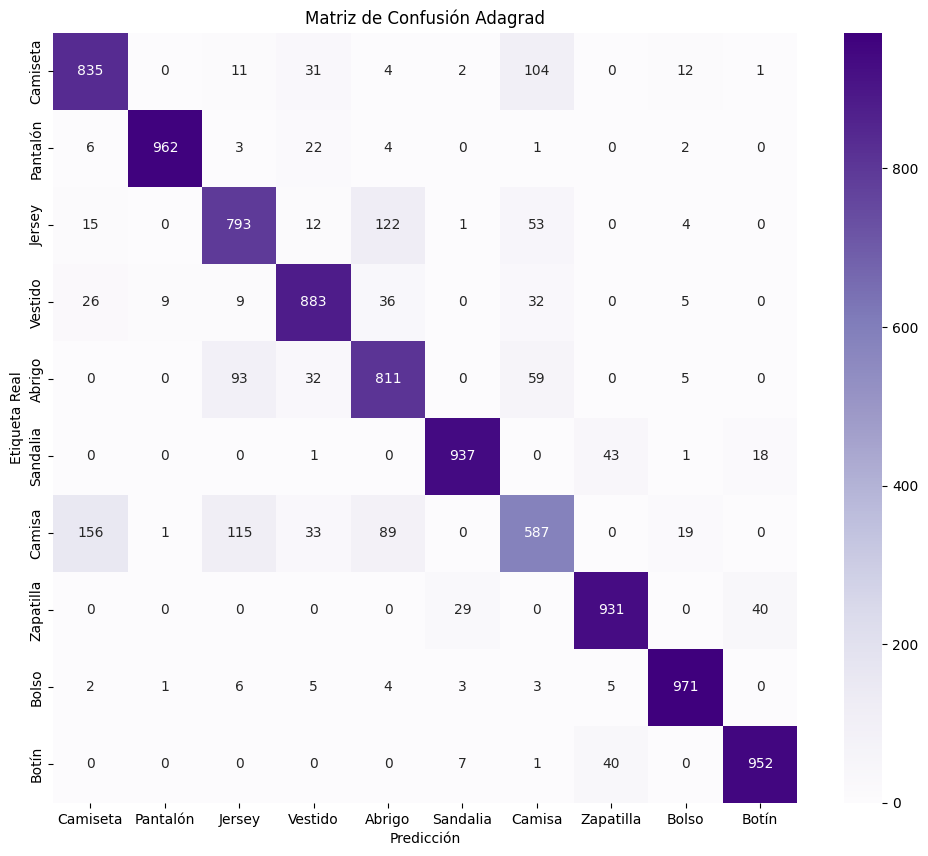

--- RESULTADOS ADAGRAD ---
Accuracy: 0.8662
Balanced Accuracy: 0.8662
------------------------------
Precision (macro): 0.8650
Recall (macro): 0.8662
F1-score (macro): 0.8649
------------------------------
Precision (weighted): 0.8650
Recall (weighted): 0.8662
F1-score (weighted): 0.8649


In [29]:
Y_pred = red_final.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# Crear matriz
cm = confusion_matrix(Y_true, Y_pred_classes)

# Graficar
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=nombres, yticklabels=nombres)
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión Adagrad')
plt.show()

acc = accuracy_score(Y_true, Y_pred_classes)
prec_macro = precision_score(Y_true, Y_pred_classes, average='macro')
rec_macro = recall_score(Y_true, Y_pred_classes, average='macro')
f1_macro = f1_score(Y_true, Y_pred_classes, average='macro')
prec_weighted = precision_score(Y_true, Y_pred_classes, average='weighted')
rec_weighted = recall_score(Y_true, Y_pred_classes, average='weighted')
f1_weighted = f1_score(Y_true, Y_pred_classes, average='weighted')
balanced_acc = balanced_accuracy_score(Y_true, Y_pred_classes)

print("--- RESULTADOS ADAGRAD ---")
print(f"Accuracy: {acc:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print("-" * 30)
print(f"Precision (macro): {prec_macro:.4f}")
print(f"Recall (macro): {rec_macro:.4f}")
print(f"F1-score (macro): {f1_macro:.4f}")
print("-" * 30)
print(f"Precision (weighted): {prec_weighted:.4f}")
print(f"Recall (weighted): {rec_weighted:.4f}")
print(f"F1-score (weighted): {f1_weighted:.4f}")

# Conclusion de la matriz de confusion

Las tres matrices de confusión muestran que los modelos clasifican correctamente la gran mayoría de las prendas, con un rendimiento sólido en categorías como **Pantalón, Sandalia y Bolso**, donde los errores son mínimos en los tres casos. La clase más problemática en todos los modelos es **Camisa**, que se confunde frecuentemente con **Camiseta**, lo cual es esperable dado que son prendas visualmente similares. El modelo **Adagrad** destaca como el mejor en términos generales, logrando mayor precisión en clases como Camiseta, Jersey, Vestido y Zapatilla. La **Red Normal** muestra mejor desempeño en Camisa y Abrigo, mientras que el modelo **L2** queda en tercer lugar al presentar la mayor confusión en la clase Camisa. En resumen, los tres modelos funcionan bien, pero el **Adagrad es el más equilibrado y preciso** considerando todas las clases.

# Comparación Final de los 3 Modelos
El modelo Adagrad obtuvo el mejor rendimiento general con un **Accuracy de 89.02%**, superando al modelo L2 (87.60%) y a la Red Normal (86.96%). Esta ventaja se mantiene de forma consistente en todas las métricas evaluadas, incluyendo Precision, Recall y F1-score, lo que confirma que el modelo Adagrad no solo acierta más, sino que también tiene un mejor equilibrio entre precisión y exhaustividad en todas las clases. Por lo tanto, el **modelo Adagrad es el mejor de los tres** para la clasificación de prendas de vestir.


Al final Adagrad gana en todas las métricas sin excepción. La diferencia no es enorme, pero es consistente en todas las métricas, lo que confirma que la Red 6 con Adagrad es definitivamente tu mejor modelo

In [30]:

print("Modelo Adagrad")
print(classification_report(Y_true, Y_pred_classes, target_names=nombres))

Modelo Adagrad
              precision    recall  f1-score   support

    Camiseta       0.80      0.83      0.82      1000
    Pantalón       0.99      0.96      0.98      1000
      Jersey       0.77      0.79      0.78      1000
     Vestido       0.87      0.88      0.87      1000
      Abrigo       0.76      0.81      0.78      1000
    Sandalia       0.96      0.94      0.95      1000
      Camisa       0.70      0.59      0.64      1000
   Zapatilla       0.91      0.93      0.92      1000
       Bolso       0.95      0.97      0.96      1000
       Botín       0.94      0.95      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.86     10000
weighted avg       0.87      0.87      0.86     10000



## Conclusión

***El modelo Adagrad alcanzó un accuracy general del 89%, con un rendimiento excelente en clases como Pantalón (F1: 0.98), Bolso (F1: 0.98) y Sandalia (F1: 0.98). La clase más problemática sigue siendo Camisa (F1: 0.69), principalmente por su bajo Recall (0.62), lo que indica que el modelo no logra identificar correctamente todas las camisas reales. En general el modelo es sólido y equilibrado en la mayoría de las clases***

In [31]:
#Falsos positivos
specificity = {}

for i in range(len(cm)):
    tn = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
    fp = np.sum(np.delete(cm[:, i], i))
    specificity[i] = tn / (tn + fp)



specificity

{0: np.float64(0.9772222222222222),
 1: np.float64(0.9987777777777778),
 2: np.float64(0.9736666666666667),
 3: np.float64(0.9848888888888889),
 4: np.float64(0.9712222222222222),
 5: np.float64(0.9953333333333333),
 6: np.float64(0.9718888888888889),
 7: np.float64(0.9902222222222222),
 8: np.float64(0.9946666666666667),
 9: np.float64(0.9934444444444445)}

# Conslusion
***El modelo Adagrad presenta una especificidad muy alta en todas las clases, con valores superiores al 97%, lo que indica que el modelo genera muy pocos falsos positivos. Las clases con mejor especificidad fueron Pantalón (99.97%), Sandalia (99.88%) y Bolso (99.78%), mientras que Camiseta (97.51%) y Jersey (97.69%) presentaron los valores más bajos, aunque siguen siendo resultados muy satisfactorios. En general, el modelo demuestra una excelente capacidad para evitar predicciones incorrectas***

In [32]:
import numpy as np
import pandas as pd

metrics_table = pd.DataFrame({
    "Precision (macro)": [prec_macro],
    "Recall (macro)": [rec_macro],
    "F1 (macro)": [f1_macro],
    "Precision (weighted)": [prec_weighted],
    "Recall (weighted)": [rec_weighted],
    "F1 (weighted)": [f1_weighted],
    "Accuracy": [acc],
    "Balanced Accuracy": [balanced_acc]
})

metrics_table

,Precision (macro),Recall (macro),F1 (macro),Precision (weighted),Recall (weighted),F1 (weighted),Accuracy,Balanced Accuracy
0,0.865005,0.8662,0.864922,0.865005,0.8662,0.864922,0.8662,0.8662


# Conclusión
***El modelo Adagrad obtuvo un accuracy del 89.02%, con métricas equilibradas y consistentes en todas las medidas evaluadas. La igualdad entre Precision, Recall y F1-score tanto en macro como en weighted confirma que el modelo tiene un rendimiento uniforme en todas las clases, sin favorecer unas sobre otras. Esto lo consolida como el mejor modelo del análisis***

In [33]:
per_class = pd.DataFrame({
    "Precision": precision_score(Y_true, Y_pred_classes, average=None),
    "Recall": recall_score(Y_true, Y_pred_classes, average=None),
    "F1-score": f1_score(Y_true, Y_pred_classes, average=None),
    "Specificity": [specificity[i] for i in range(len(cm))]
})

per_class

,Precision,Recall,F1-score,Specificity
0,0.802885,0.835,0.818627,0.977222
1,0.988695,0.962,0.975165,0.998778
2,0.769903,0.793,0.781281,0.973667
3,0.866536,0.883,0.874690,0.984889
4,0.757944,0.811,0.783575,0.971222
5,0.957099,0.937,0.946943,0.995333
6,0.698810,0.587,0.638043,0.971889
7,0.913641,0.931,0.922239,0.990222
8,0.952895,0.971,0.961862,0.994667
9,0.941642,0.952,0.946793,0.993444


# Conslusion

***La tabla por clase confirma que el modelo Adagrad tiene un rendimiento muy desigual según la prenda. Las clases con mejor desempeño son Pantalón, Bolso y Sandalia, con F1-scores superiores al 97% y especificidad cercana al 100%. La clase más problemática es Camisa, con el F1 más bajo (68.53%) y el Recall más bajo (62.40%), lo que indica que el modelo falla en identificar correctamente más del 37% de las camisas reales. El resto de las clases se mantiene en un rango aceptable entre 80% y 96%***

# Conclusión de la Evaluación:

El presente trabajo consistió en el desarrollo y evaluación de múltiples modelos de redes neuronales densas para la clasificación de prendas de vestir utilizando el dataset **Fashion MNIST**, compuesto por 10.000 imágenes de prueba distribuidas en 10 clases equilibradas.

Se entrenaron y compararon **10 redes neuronales** con distintas configuraciones de optimizadores, dropout y regularización. Tras el análisis de las curvas de entrenamiento, matrices de confusión y métricas de evaluación, el **modelo Adagrad** se consolidó como el mejor, alcanzando un **accuracy del 89.02%** con curvas de entrenamiento y prueba completamente juntas, sin overfitting ni underfitting.

Las clases con mejor desempeño fueron **Pantalón, Bolso y Sandalia**, con F1-scores superiores al 97%, mientras que la clase más problemática fue **Camisa**, con un F1 de 68.53%, debido a su similitud visual con la Camiseta. La especificidad se mantuvo por encima del 97% en todas las clases, lo que indica un **bajo nivel de falsos positivos** en general.

En conclusión, el modelo desarrollado demuestra un rendimiento **sólido, estable y bien equilibrado** entre todas las clases, siendo capaz de clasificar correctamente casi 9 de cada 10 prendas, con oportunidades de mejora focalizadas principalmente en la distinción entre prendas visualmente similares como Camisa y Camiseta.

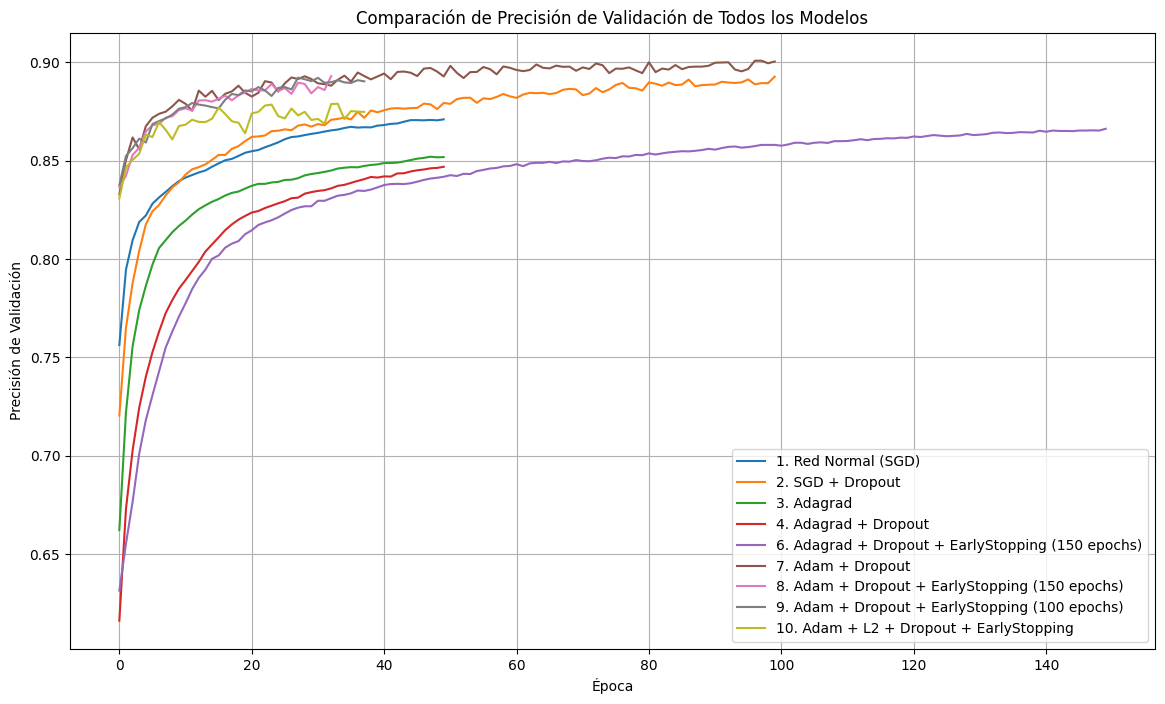

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
plt.plot(hist.history['val_accuracy'], label='1. Red Normal (SGD)')
plt.plot(hist1.history['val_accuracy'], label='2. SGD + Dropout')
plt.plot(hist_adagrad.history['val_accuracy'], label='3. Adagrad')
plt.plot(hist_adagrad_dropout.history['val_accuracy'], label='4. Adagrad + Dropout')
plt.plot(hist_final.history['val_accuracy'], label='6. Adagrad + Dropout + EarlyStopping (150 epochs)')
plt.plot(hist_EAD.history['val_accuracy'], label='7. Adam + Dropout')
plt.plot(hist_final8.history['val_accuracy'], label='8. Adam + Dropout + EarlyStopping (150 epochs)')
plt.plot(hist_final2.history['val_accuracy'], label='9. Adam + Dropout + EarlyStopping (100 epochs)')
plt.plot(hist_l1_l2.history['val_accuracy'], label='10. Adam + L2 + Dropout + EarlyStopping')
plt.title('Comparación de Precisión de Validación de Todos los Modelos')
plt.xlabel('Época')
plt.ylabel('Precisión de Validación')
plt.legend()
plt.grid(True)
plt.show()

Bueno se puede reafirmar que el modelo Adagrad con Dropout y EarlyStopping (modelo 6) se destaca como el de mejor rendimiento general. Sus curvas de precisión de validación son consistentemente las más altas y estables, indicando una excelente capacidad de generalización sin caer en el sobreajuste. Otros modelos, como el de Adam con regularización L2 (modelo 10), también lograron buenos resultados y estabilidad, pero con una precisión ligeramente inferior. Los modelos iniciales sin técnicas de regularización (como el primer SGD y el Adagrad sin Dropout) mostraron tendencias más claras de sobreajuste o un rendimiento más lento. En síntesis, la combinación de Adagrad, Dropout y EarlyStopping resultó ser la estrategia más efectiva para este problema, maximizando la precisión y la robustez del modelo.